# Heart Disease Prediction — 5 Machine Learning Models

This notebook uses `values.csv` and `labels.csv`, merges them on `patient_id`, and evaluates exactly five classification models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# If the CSV files are in the same folder as this notebook:
values = pd.read_csv(r"C:\Users\91929\Downloads\values.csv")
labels = pd.read_csv(r"C:\Users\91929\Downloads\labels (1).csv")

df = pd.merge(values, labels, on="patient_id", how="inner")
print("Merged dataset shape:", df.shape)
display(df.head())
print("\nTarget distribution:")
print(df["heart_disease_present"].value_counts())

Merged dataset shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0



Target distribution:
heart_disease_present
0    100
1     80
Name: count, dtype: int64


## Prepare data

`patient_id` is an identifier, so it is excluded from model features. `thal` is categorical and is one-hot encoded. The remaining columns are numeric.

In [3]:
X = df.drop(columns=["patient_id", "heart_disease_present"])
y = df["heart_disease_present"]

categorical_features = ["thal"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 144
Testing samples: 36


## Build and evaluate exactly 5 models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9167,0.8421,1.0000,0.9143,0.9562
1,Logistic Regression,0.8056,0.7647,0.8125,0.7879,0.9406
2,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9359
3,K-Nearest Neighbors,0.8889,0.8750,0.8750,0.8750,0.9141
4,Decision Tree,0.8056,0.8462,0.6875,0.7586,0.8000


## Detailed evaluation

In [5]:
for name, pipe in fitted_models.items():
    pred = pipe.predict(X_test)
    print("=" * 70)
    print(name)
    print(classification_report(y_test, pred, target_names=["No Heart Disease", "Heart Disease"], zero_division=0))

Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.80      0.82        20
   Heart Disease       0.76      0.81      0.79        16

        accuracy                           0.81        36
       macro avg       0.80      0.81      0.80        36
    weighted avg       0.81      0.81      0.81        36

K-Nearest Neighbors
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.90      0.90        20
   Heart Disease       0.88      0.88      0.88        16

        accuracy                           0.89        36
       macro avg       0.89      0.89      0.89        36
    weighted avg       0.89      0.89      0.89        36

Decision Tree
                  precision    recall  f1-score   support

No Heart Disease       0.78      0.90      0.84        20
   Heart Disease       0.85      0.69      0.76        16

        accuracy                           0.81        36
       mac

## Compare the five models

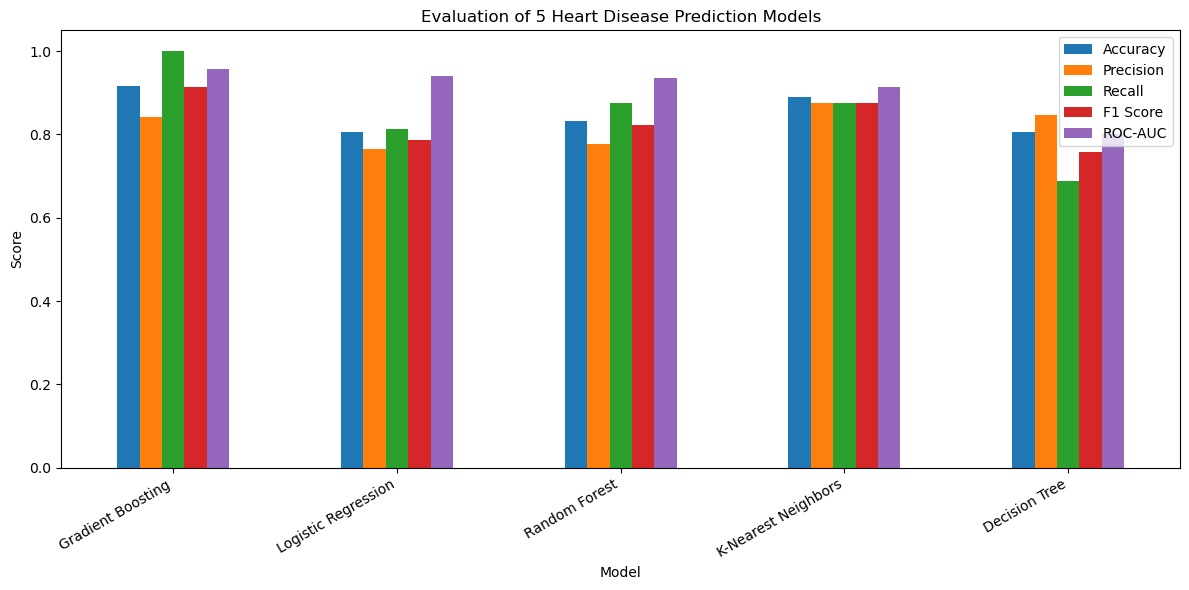

Best model by ROC-AUC: Gradient Boosting
ROC-AUC: 0.9562


In [6]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
ax = results_df.set_index("Model")[metrics].plot(kind="bar", figsize=(12, 6))
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Evaluation of 5 Heart Disease Prediction Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print("Best model by ROC-AUC:", best_model["Model"])
print("ROC-AUC:", round(best_model["ROC-AUC"], 4))

### Notes
- The notebook uses a stratified 80/20 train-test split with `random_state=42` for reproducibility.
- The five models are Logistic Regression, KNN, Decision Tree, Random Forest, and Gradient Boosting.
- The best model is selected by ROC-AUC on the held-out test set.
- The project brief asks for multiple-model performance comparison and a production recommendation; this notebook provides that comparison. fileciteturn0file0L47-L54